# 4B. Modes of Variability API Demo

This notebook demonstrates how to use the PCMDI Metrics variability mode API to analyze climate model outputs and compare them with observations.

## What This Notebook Demonstrates

This notebook shows you how to:

- **Compute variability modes** (NAO, NAM, PDO, NPGO) from climate model data
- **Compare with observations** using comprehensive evaluation metrics
- **Choose between methods** (EOF vs CBF) for different analysis needs
- **Understand the results** including diagnostics, metrics, and their scientific meaning
- **Visualize patterns** using EOF spatial patterns and PC time series
- **Configure the analysis** with options like unit conversion, land masking, and time periods

All examples use CMIP5 demo data and can be easily adapted to your own datasets.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Import variability mode API functions
from pcmdi_metrics.variability_mode import NAO, NAM, SAM, PDO, NPGO

print("Imports successful!")

Imports successful!


## Quick Start

Here's the simplest possible example - computing NAO from model data in just a few lines:

```python
import xarray as xr
from pcmdi_metrics.variability_mode import NAO

# Load your data
model_ds = xr.open_dataset('your_psl_data.nc')

# Compute NAO
results = NAO(model_ds, data_var='psl')

# Access the results
print(f"DJF variance fraction: {results['DJF']['diagnostics']['frac']:.3f}")
```

Let's explore the full capabilities with real CMIP5 data below!

---

**Key Concepts:**

- **Diagnostics** contain the model's own statistics (variance fraction, PC std dev, spatial means)
- **Metrics** contain comparison statistics when reference data is provided (correlations, RMS errors, bias)
- **Subdomain metrics** assess performance in the EOF core region (e.g., NAO: 20-80N, 90W-40E)
- **Global teleconnection metrics** (with `_glo` suffix) assess how well remote influences are captured

---

Let's begin with the setup!

## Setup: Define Data Paths

Download the demo data following the [Demo 0 Notebook](https://pcmdi.github.io/pcmdi_metrics/examples/Demo_0_download_data.html).

In [2]:
# Base directory for demo data
base_dir = Path("./demo_data")

# Model data paths
model_psl_path = base_dir / "CMIP5_demo_data" / "psl_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
model_ts_path = base_dir / "CMIP5_demo_data" / "ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
model_sftlf_path = base_dir / "CMIP5_demo_data" / "sftlf_fx_ACCESS1-0_amip_r0i0p0.nc"

# Reference data paths
ref_psl_path = base_dir / "obs4MIPs_PCMDI_monthly" / "NOAA-ESRL-PSD" / "20CR" / "mon" / "psl" / "gn" / "v20210727" / "psl_mon_20CR_PCMDI_gn_187101-201212.nc"
ref_ts_path = base_dir / "obs4MIPs_PCMDI_monthly" / "MOHC" / "HadISST-1-1" / "mon" / "ts" / "gn" / "v20260416" / "ts_mon_HadISST-1-1_PCMDI_gn_187001-202501.nc"

# Verify files exist
for path in [model_psl_path, model_ts_path, model_sftlf_path, ref_psl_path, ref_ts_path]:
    if path.exists():
        print(f"✓ {path.name}")
    else:
        print(f"✗ MISSING: {path}")

✓ psl_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc
✓ ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc
✓ sftlf_fx_ACCESS1-0_amip_r0i0p0.nc
✓ psl_mon_20CR_PCMDI_gn_187101-201212.nc
✓ ts_mon_HadISST-1-1_PCMDI_gn_187001-202501.nc


In [3]:
# Load model data
model_psl = xr.open_dataset(model_psl_path)
model_ts = xr.open_dataset(model_ts_path)
model_sftlf = xr.open_dataset(model_sftlf_path)

# Load reference data
ref_psl = xr.open_dataset(ref_psl_path)
ref_ts = xr.open_dataset(ref_ts_path)

print("Model PSL shape:", model_psl['psl'].shape)
print("Model TS shape:", model_ts['ts'].shape)
print("Land fraction shape:", model_sftlf['sftlf'].shape)
print("\nReference PSL shape:", ref_psl['psl'].shape)
print("Reference TS shape:", ref_ts['ts'].shape)

Model PSL shape: (1872, 145, 192)
Model TS shape: (1872, 145, 192)
Land fraction shape: (145, 192)

Reference PSL shape: (1704, 91, 180)
Reference TS shape: (1861, 180, 360)


## Example 1: Basic Mode Calculation (NAO)

Let's start with the simplest use case - computing NAO from model data without reference observations.

This example shows:
- Computing a variability mode with default settings
- Automatic unit conversion (Pa to hPa)
- Accessing diagnostics (variance fraction, PC standard deviation)
- Time period selection

In [4]:
print("Computing NAM with reference data...")
nao_results = NAO(
    model_psl,
    data_var='psl',
    seasons=['DJF', 'JJA'],  # Only winter and summer
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa
    start_year=1900,
    end_year=2005
)

Computing NAM with reference data...
Converting units by  divide 100.0


In [ ]:
# Plot NAO EOF pattern for DJF

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

eof_pattern = nao_results["DJF"]["diagnostics"]["eof_pattern"]

eof_pattern.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    cbar_kwargs={"label": "EOF amplitude"}
)

# Coastline only
ax.coastlines(linewidth=0.8)

# Simple gridlines (no labels to avoid version compatibility issues)
ax.gridlines(
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

ax.set_title("NAO EOF Pattern (DJF) - Model")

plt.tight_layout()
plt.show()

## Example 2: Comprehensive Metrics Display (NAM)

Now let's compute a variability mode with observational reference data to get evaluation metrics.

This example shows:
- How metrics are computed when reference data is provided
- Complete display of all 9 comparison statistics
- Scientific descriptions for each metric
- Distinction between subdomain and global teleconnection metrics

In [6]:
print("Computing NAM with reference data...")
nam_results = NAM(
    model_psl,
    data_var='psl',
    reference_ds=ref_psl,
    seasons=['DJF', 'JJA'],  # Only winter and summer
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa
    reference_units_adjust=(True, 'divide', 100.0),  # Pa to hPa
    start_year=1900,
    end_year=2005
)

Computing NAM with reference data...
Converting units by  divide 100.0
Converting units by  divide 100.0


In [ ]:
# Plot NAM EOF pattern for DJF

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={
        "projection": ccrs.NorthPolarStereo()
    }
)

eof_pattern = nam_results["DJF"]["diagnostics"]["eof_pattern"]

eof_pattern.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    cbar_kwargs={"label": "EOF amplitude"}
)

# Show latitudes from 20°N to 90°N
ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())

# Coastline only
ax.coastlines(linewidth=0.8)

# Circular map boundary
theta = np.linspace(0, 2 * np.pi, 200)
center, radius = [0.5, 0.5], 0.5
circle = plt.Circle(
    center,
    radius,
    transform=ax.transAxes,
    facecolor="none",
    edgecolor="black",
    linewidth=1.0,
    zorder=10
)
ax.add_patch(circle)

# Simple gridlines (no labels to avoid version compatibility issues)
ax.gridlines(
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

ax.set_title("NAM EOF Pattern (DJF) - North Polar Projection")

plt.tight_layout()
plt.show()

In [17]:
nam_results['DJF']['metrics']

{'rms': 0.5744337380453614,
 'rms_glo': 0.37577792532746496,
 'rmsc': 0.35982744956247725,
 'rmsc_glo': 0.41440570733751625,
 'cor': 0.935262099788672,
 'cor_glo': 0.9141339596458946,
 'bias': 0.0030016601934660264,
 'bias_glo': 0.03907360776119204,
 'stdv_pc_ratio_to_obs': 0.8105150390693061}

## Example 3: SST-Based Mode (PDO) with Comparing Analysis Methods (PDO)

This example compares different approaches to analyzing PDO with reference data.

We'll demonstrate three methods:
1. **Individual calculations** - Model and reference computed separately (no metrics)
2. **EOF method with metrics** - Both compute their own EOFs, then compare
3. **CBF method** - Model projected onto reference EOFs for direct comparison

Understanding these differences helps you choose the right method for your analysis.

### 3.1: Individual Calculations

First, let's compute model and reference PDO separately (without metrics).

In [8]:
print("Computing PDO with model and reference data...\n")

# PDO with model data only (diagnostics only)
pdo_model = PDO(
    model_ts,
    data_var='ts',
    start_year=1900,
    end_year=2005,
    units_adjust=(True, 'subtract', 273.15),  # K to C
)

print("PDO (model - diagnostics):")
print(f"  Variance fraction: {pdo_model['monthly']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {pdo_model['monthly']['diagnostics']['stdv_pc']:.2f}")

pdo_ref = PDO(
    ref_ts,
    data_var='ts',
    start_year=1900,
    end_year=2005,
    units_adjust=(True, 'subtract', 273.15),  # K to C
)

print("PDO (ref - diagnostics):")
print(f"  Variance fraction: {pdo_ref['monthly']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {pdo_ref['monthly']['diagnostics']['stdv_pc']:.2f}")

Computing PDO with model and reference data...

Converting units by  subtract 273.15


/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(


PDO (model - diagnostics):
  Variance fraction: 0.1520
  PC stdv: 0.22
Converting units by  subtract 273.15


/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(


PDO (ref - diagnostics):
  Variance fraction: 0.2610
  PC stdv: 0.24


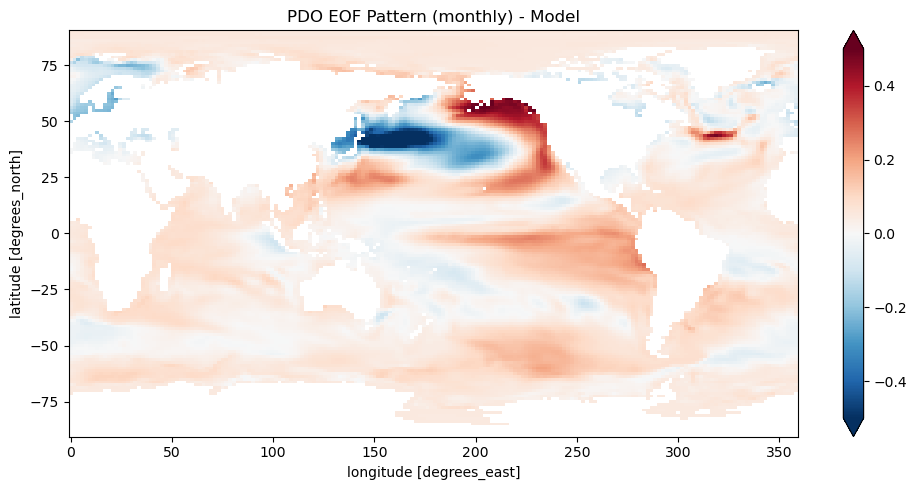

In [9]:
# Plot PDO EOF pattern
fig, ax = plt.subplots(figsize=(10, 5))
eof_pattern = pdo_model['monthly']['diagnostics']['eof_pattern']
eof_pattern.plot(ax=ax, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_title('PDO EOF Pattern (monthly) - Model')
plt.tight_layout()
plt.show()

### 3.2: PDO with Model and Reference Data to enable metrics calculation

PDO uses the 1st EOF of SST and defaults to monthly analysis for the reference dataset and model. Providing reference dataset enables additional calculation for evaluation metrics.

In [10]:
pdo_model_with_ref = PDO(
    model_ts,
    data_var='ts',
    reference_ds=ref_ts,
    land_mask=True,
    start_year=1900,
    end_year=2005,
    units_adjust=(True, 'subtract', 273.15),  # K to C
)

Converting units by  subtract 273.15


/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(
/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(


In [11]:
pdo_model_with_ref['monthly']['metrics']

{'rms': 0.19730699293185888,
 'rms_glo': 0.11597448404959312,
 'rmsc': 0.6886745261245016,
 'rmsc_glo': 0.7828663652732126,
 'cor': 0.762863699089476,
 'cor_glo': 0.6935601175817083,
 'bias': 0.004169892132225708,
 'bias_glo': -0.042598168879460226,
 'stdv_pc_ratio_to_obs': 0.9407360648044291}

### 3.3: CBF Method

The Common Basis Function (CBF) method projects the model data onto the reference EOFs, providing a more direct comparison.

In [12]:
# PDO with both model and reference data (diagnostics + metrics)
pdo_model_cbf = PDO(
    model_ts,
    data_var='ts',
    reference_ds=ref_ts,
    land_mask=True,
    start_year=1900,
    end_year=2005,
    method='cbf',
    units_adjust=(True, 'subtract', 273.15),  # K to C
)

print("\nPDO (with reference - diagnostics + metrics):")
print(f"  Variance fraction: {pdo_model_cbf['monthly']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {pdo_model_cbf['monthly']['diagnostics']['stdv_pc']:.2f}")
print("\n  Metrics (comparison with reference):")
print(f"    Correlation: {pdo_model_cbf['monthly']['metrics']['cor']:.4f}")
print(f"    RMS error: {pdo_model_cbf['monthly']['metrics']['rms']:.4f}")
print(f"    Bias: {pdo_model_cbf['monthly']['metrics']['bias']:.4f}")

print("\nNote: Metrics are only available when reference_ds is provided.")

Converting units by  subtract 273.15


/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(
/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(



PDO (with reference - diagnostics + metrics):
  Variance fraction: 0.1353
  PC stdv: 0.18

  Metrics (comparison with reference):
    Correlation: 0.9160
    RMS error: 0.1179
    Bias: 0.0026

Note: Metrics are only available when reference_ds is provided.


### 3.4: Visual Comparison

Let's visualize the three EOF patterns side by side to see the differences between methods.

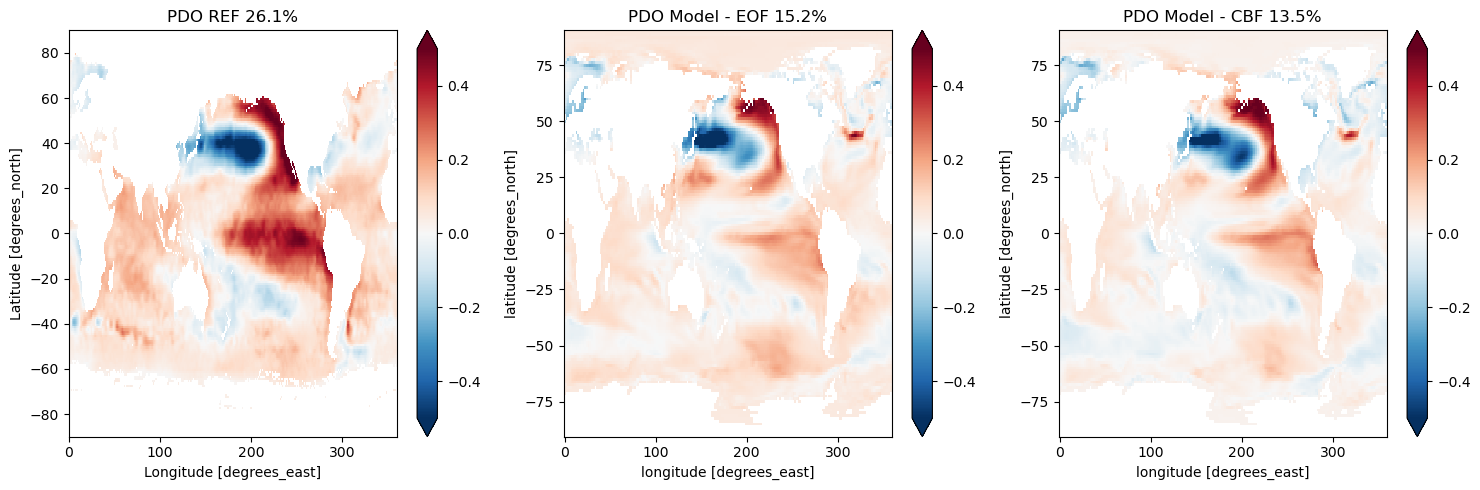

In [13]:
# Compare EOF patterns obtained from the reference and model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# REF
eof_ref = pdo_ref['monthly']['diagnostics']['eof_pattern']
eof_ref.plot(ax=axes[0], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0].set_title(f"PDO REF {pdo_ref['monthly']['diagnostics']['frac'] * 100:.1f}%")

# Model (EOF)
eof_model = pdo_model['monthly']['diagnostics']['eof_pattern']
eof_model.plot(ax=axes[1], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1].set_title(f"PDO Model - EOF {pdo_model['monthly']['diagnostics']['frac'] * 100:.1f}%")

# Model (CBF)
eof_model = pdo_model_cbf['monthly']['diagnostics']['cbf_pattern']
eof_model.plot(ax=axes[2], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[2].set_title(f"PDO Model - CBF {pdo_model_cbf['monthly']['diagnostics']['frac'] * 100:.1f}%")

plt.tight_layout()
plt.show()

## Example 4: Higher EOF Modes (NPGO)

Beyond the leading EOF, you can analyze secondary modes. Here we compute NPGO, which is the 2nd EOF of North Pacific SST.

This example shows:
- Computing higher EOF modes (2nd, 3rd, etc.)
- The API automatically extracts the correct EOF number for each mode

In [14]:
print("Computing NPGO with model...\n")

# PDO with model data only (diagnostics only)
npgo_results = NPGO(
    model_ts,
    data_var='ts',
    start_year=1900,
    end_year=2005,
    units_adjust=(True, 'subtract', 273.15),  # K to C
)

print("NPGO (model - diagnostics):")
print(f"  Variance fraction: {pdo_model['monthly']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {pdo_model['monthly']['diagnostics']['stdv_pc']:.2f}")

Computing NPGO with model...

Converting units by  subtract 273.15


/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(


NPGO (model - diagnostics):
  Variance fraction: 0.1520
  PC stdv: 0.22


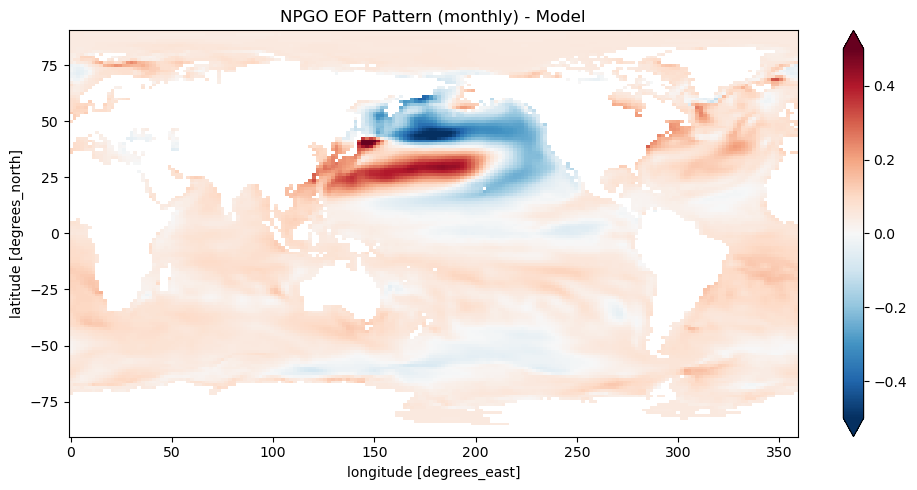

In [15]:
# Plot NPGO EOF pattern
fig, ax = plt.subplots(figsize=(10, 5))
eof_pattern = npgo_results['monthly']['diagnostics']['eof_pattern']
eof_pattern.plot(ax=ax, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_title('NPGO EOF Pattern (monthly) - Model')
plt.tight_layout()
plt.show()

## Example 5: Time Series Analysis

The principal component (PC) time series captures the temporal evolution of each variability mode. Let's extract and visualize it.

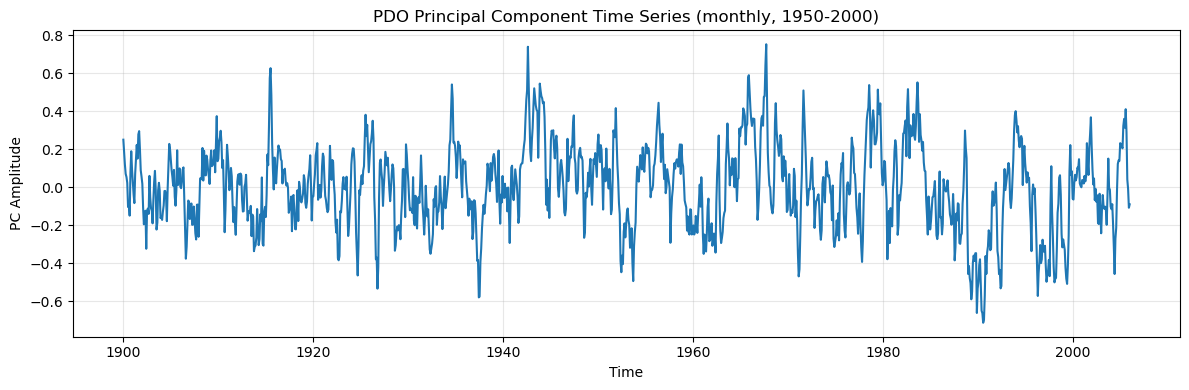

PC time series shape: (1272,)
PC mean: -6.72e-18
PC std: 0.22


In [16]:
# Extract PC time series
pc_ts = pdo_model['monthly']['diagnostics']['pc_timeseries']

# Plot time series
fig, ax = plt.subplots(figsize=(12, 4))
pc_ts.plot(ax=ax)
ax.set_title('PDO Principal Component Time Series (monthly, 1950-2000)')
ax.set_xlabel('Time')
ax.set_ylabel('PC Amplitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC time series shape: {pc_ts.shape}")
print(f"PC mean: {float(pc_ts.mean()):.2e}")
print(f"PC std: {float(pc_ts.std()):.2f}")

## Summary

This notebook demonstrated:

1. ✅ **Test 1**: Basic NAO computation with unit conversion (Pa to hPa) - diagnostics only
2. ✅ **Test 2**: NAM with reference data - comprehensive display of all comparison metrics with descriptions
4. ✅ **Test 3**: PDO with model and reference data
   - **3.1**: PDO calculated from model and reference data individually
   - **3.2**: PDO with reference to enable metrics calculation (EOF method)
   - **3.3**: PDO with CBF method for model-reference comparison
   - **3.4**: Visual comparison of EOF patterns from reference, model EOF, and model CBF
5. ✅ **Test 4**: NPGO (2nd EOF) with reference data - demonstrates higher EOF modes
6. ✅ **Test 5**: PC time series extraction and visualization

### Key Features Tested:
- ✅ Atmospheric modes (NAO, NAM) and SST-based modes (PDO, NPGO)
- ✅ EOF analysis with and without reference data
- ✅ CBF (Common Basis Function) method for model-reference comparison
- ✅ Unit conversion: Pa to hPa (divide by 100), K to °C (subtract 273.15)
- ✅ Automatic land masking for SST modes
- ✅ Time subsetting (start_year, end_year)
- ✅ Multiple season options (DJF, JJA, monthly)
- ✅ Comprehensive metrics display with descriptions (subdomain vs global teleconnection)
- ✅ Visualization of EOF patterns and PC time series

### Key Findings:
- The API successfully handles all variability modes with realistic results
- Unit conversion works correctly for both model and reference datasets
- EOF method computes model's own EOFs independently from reference
- CBF method projects model data onto reference EOFs for direct comparison
- Metrics section contains only comparison statistics (no duplication with diagnostics)
- Subdomain metrics assess performance in the EOF core region
- Global teleconnection metrics assess how well remote influences are captured
- Automatic land masking generates appropriate ocean masks when not provided
- All 9 comparison metrics are clearly documented with scientific descriptions
- EOF patterns and PC time series are properly extracted and visualizable

### Available Modes

Beyond NAO, NAM, PDO, and NPGO demonstrated here, you can also compute:
- **SAM** - Southern Annular Mode
- **PNA** - Pacific North American Pattern
- **NPO** - North Pacific Oscillation  
- **AMO** - Atlantic Multidecadal Oscillation
- **PSA1, PSA2** - Pacific-South American Patterns

All modes use the same API structure!

### Getting Help

- **Documentation**: [pcmdi.github.io/pcmdi_metrics](https://pcmdi.github.io/pcmdi_metrics)
- **Issues**: [github.com/PCMDI/pcmdi_metrics/issues](https://github.com/PCMDI/pcmdi_metrics/issues)
- **Email**: pcmdi-metrics@llnl.gov

### Citation

If you use this package in your research, please cite:

Lee, J., K. Sperber, P. Gleckler, C. Bonfils, and K. Taylor, 2019: Quantifying the Agreement Between Observed and Simulated Extratropical Modes of Interannual Variability. *Climate Dynamics*, 52, 4057-4089. [https://doi.org/10.1007/s00382-018-4355-4](https://doi.org/10.1007/s00382-018-4355-4)